# K-Means Customer Segmentation: Part 1: identifying hidden customer segments through unsupervised clustering

### Purpose: 
Leverage unsupervised kmeans clustering to identify hidden audience segments to guide future marketing creative, placement and optimize marketing budgets with deep insights.

### Business Problem: 
- Inefficient marketing spend 
- Utilizing a generalized strategy increases marketing spend by wasting budget on demographic segments with a near-zero probability of conversion

### Low campaign conversion rates 
    * One-size-fits-all approaches for campaigns results in ignored promotions and stagnant sales throughput, despite high-volume outreach


### Poor differentiation between high-value and low-value customers 
    * Without customer segmentation, customers who are highly profitable are treated the same as one-off buyers, thus leaving revenue streams open to competitor offers 

### Missed upselling and retention opportunities 
    * High-probability cross-sell opportunities are missed and instead the company waits for customers to churn before trying to save them

## 1. Load data & setup

In [186]:
# Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn import set_config
from scipy import stats
import seaborn as sns

set_config(transform_output="pandas")

# Load dataset (relative path from experiments/ folder)
df = pd.read_csv("../data/preprocessed/david_preprocessed.csv") 

print("Initial shape:", df.shape)
print(df.head(3))
print(df.info())
df.columns.tolist

Initial shape: (2229, 30)
     ID Education   Income Dt_Customer  Recency  MntWines  MntFruits  \
0  5524  Graduate  58138.0  2012-09-04       58       635         88   
1  2174  Graduate  46344.0  2014-03-08       38        11          1   
2  4141  Graduate  71613.0  2013-08-21       26       426         49   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  AcceptedCmp2  \
0              546              172                88  ...             0   
1                6                2                 1  ...             0   
2              127              111                21  ...             0   

   Complain  Response  Age  Customer_Tenure_Days  Living_With  \
0         0         1   57                   663        Alone   
1         0         0   60                   113        Alone   
2         0         0   49                   312      Partner   

   Children_at_home  Family_Size  Total_Spending  Total_Purchases  
0                 0            1            1617   

<bound method IndexOpsMixin.tolist of Index(['ID', 'Education', 'Income', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'Living_With', 'Children_at_home', 'Family_Size', 'Total_Spending',
       'Total_Purchases'],
      dtype='str')>

## 3. Preprocessing (encode, scale)

One-hot encode categoricals, exclude target/AcceptedCmp, and standardize features for clustering.

In [187]:
df_david = df.copy()

df_david['Pct_Fruits'] = df_david['MntFruits'] / df_david['Total_Spending']
df_david['Pct_Sweet'] = df_david['MntSweetProducts'] / df_david['Total_Spending']
df_david['Pct_Wine'] = df_david['MntWines'] / df_david['Total_Spending']
df_david['Pct_Meat'] = df_david['MntMeatProducts'] / df_david['Total_Spending']
df_david['Pct_Gold'] = df_david['MntGoldProds'] / df_david['Total_Spending']
df_david['Pct_Fish'] = df_david['MntFishProducts'] / df_david['Total_Spending']

df_david['Pct_WebPurchases'] = df_david['NumWebPurchases'] / df_david['Total_Purchases']
df_david['Pct_CatalogPurchases'] = df_david['NumCatalogPurchases'] / df_david['Total_Purchases']
df_david['Pct_StorePurchases'] = df_david['NumStorePurchases'] / df_david['Total_Purchases']

df_david = df_david.dropna(subset=[
    'Pct_WebPurchases',
    'Pct_CatalogPurchases',
    'Pct_StorePurchases'
])

df_david.head()

,ID,Education,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Total_Purchases,Pct_Fruits,Pct_Sweet,Pct_Wine,Pct_Meat,Pct_Gold,Pct_Fish,Pct_WebPurchases,Pct_CatalogPurchases,Pct_StorePurchases
0,5524,Graduate,58138.0,2012-09-04,58,635,88,546,172,88,...,22,0.054422,0.054422,0.392703,0.337662,0.054422,0.106370,0.363636,0.454545,0.181818
1,2174,Graduate,46344.0,2014-03-08,38,11,1,6,2,1,...,4,0.037037,0.037037,0.407407,0.222222,0.222222,0.074074,0.250000,0.250000,0.500000
2,4141,Graduate,71613.0,2013-08-21,26,426,49,127,111,21,...,20,0.063144,0.027062,0.548969,0.163660,0.054124,0.143041,0.400000,0.100000,0.500000
3,6182,Graduate,26646.0,2014-02-10,26,11,4,20,10,3,...,6,0.075472,0.056604,0.207547,0.377358,0.094340,0.188679,0.333333,0.000000,0.666667
4,5324,PhD,58293.0,2014-01-19,94,173,43,118,46,27,...,14,0.101896,0.063981,0.409953,0.279621,0.035545,0.109005,0.357143,0.214286,0.428571


In [188]:
from sklearn import set_config
set_config(transform_output="pandas")

scaler = StandardScaler()

# 1. Encode
df_encoded = pd.get_dummies(df_david, columns=['Education', 'Living_With'], drop_first=True)

# 2. Select numeric features
numeric_features = df_encoded.select_dtypes(include=['int64', 'float64', 'uint8']).columns
exclude = ['ID','AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5','Dt_Customer', 'Income', 'Total_Spending', 'Total_Purchases', 'MntFruits', 'MntSweetProducts', 'MntWines', 'MntMeatProducts', 'MntFishProducts','MntGoldProds',
                        'Complain','Response', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
numeric_features = [c for c in numeric_features if c not in exclude]

# 3. Scale (returns DataFrame with set_config)
X = scaler.fit_transform(df_encoded[numeric_features])

X.head()


,Recency,NumDealsPurchases,NumWebVisitsMonth,Age,Customer_Tenure_Days,Children_at_home,Family_Size,Pct_Fruits,Pct_Sweet,Pct_Wine,Pct_Meat,Pct_Gold,Pct_Fish,Pct_WebPurchases,Pct_CatalogPurchases,Pct_StorePurchases
0,0.306756,0.371323,0.713131,1.015057,1.528763,-1.267088,-1.762631,0.092262,0.058756,-0.293270,0.716883,-0.603043,0.449354,0.274806,2.116361,-2.187471
1,-0.383996,-0.167265,-0.132667,1.271162,-1.194012,1.393857,0.444377,-0.220399,-0.225324,-0.228766,-0.213832,0.935816,0.034374,-0.662883,0.627477,-0.039629
2,-0.798447,-0.705852,-0.555566,0.332111,-0.208862,-1.267088,-0.659127,0.249135,-0.388326,0.392196,-0.685982,-0.605776,0.920560,0.574867,-0.464370,-0.039629
3,-0.798447,-0.167265,0.290232,-1.289886,-1.065299,0.063384,0.444377,0.470840,0.094411,-1.105456,1.036927,-0.236965,1.506980,0.024756,-1.192269,1.085430
4,1.550110,1.448497,-0.132667,-1.033781,-0.956388,0.063384,0.444377,0.946071,0.214962,-0.217602,0.248934,-0.776157,0.483211,0.221224,0.367514,-0.521798


## 4. Choose k (elbow + silhouette)

Evaluate WSSD and silhouette score across k=1..10 to select optimal number of clusters.

In [189]:
clust_ks = pd.DataFrame(columns=["k", "wssd"])

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    current_k = pd.DataFrame({"k": [k], "wssd": [kmeans.inertia_]})
    clust_ks = pd.concat([clust_ks, current_k], ignore_index=True)

clust_ks

,k,wssd
0,1,35600.0
1,2,30254.039653
2,3,26303.131066
3,4,24628.357972
4,5,23576.762786
5,6,22643.047305
6,7,21994.847017
7,8,21370.088563
8,9,20817.090844
9,10,20306.019341


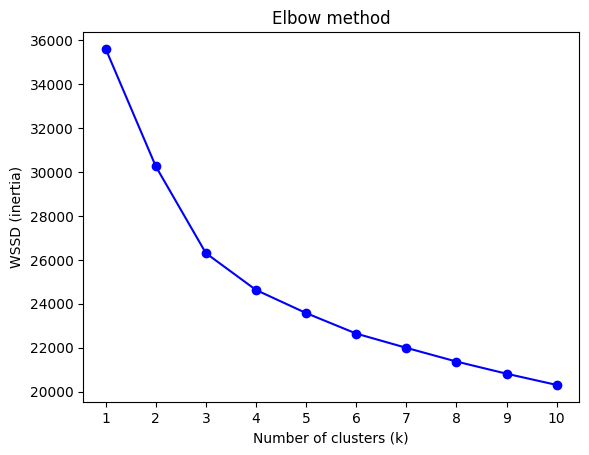

In [190]:
import matplotlib.pyplot as plt
plt.plot(clust_ks["k"], clust_ks["wssd"], "bo-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WSSD (inertia)")
plt.title("Elbow method")
plt.xticks(range(1, 11))
plt.show()

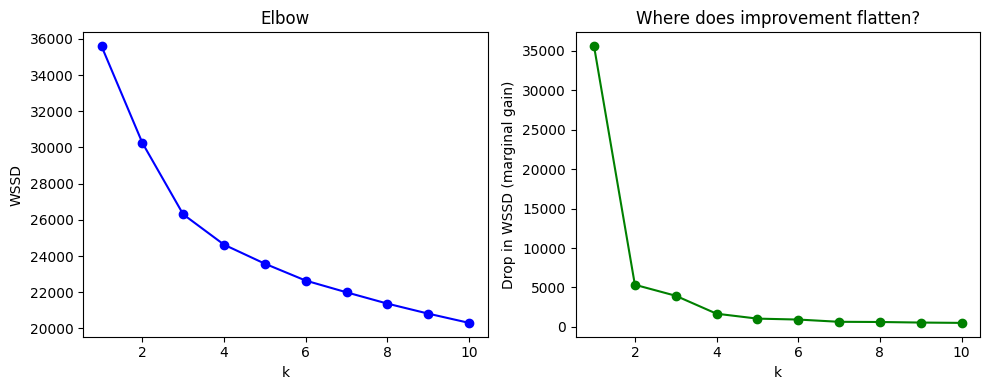

In [191]:
# Add a column for the decrease in WSSD when going from k-1 to k
clust_ks['wssd_drop'] = clust_ks['wssd'].diff().abs()
clust_ks['wssd_drop'] = clust_ks['wssd_drop'].fillna(clust_ks['wssd'].iloc[0])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(clust_ks["k"], clust_ks["wssd"], "bo-")
plt.xlabel("k")
plt.ylabel("WSSD")
plt.title("Elbow")

plt.subplot(1, 2, 2)
plt.plot(clust_ks["k"], clust_ks["wssd_drop"], "go-")
plt.xlabel("k")
plt.ylabel("Drop in WSSD (marginal gain)")
plt.title("Where does improvement flatten?")
plt.tight_layout()
plt.show()


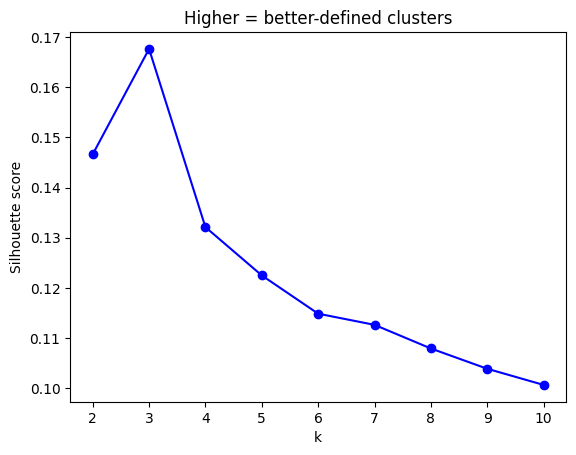

In [192]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.plot(range(2, 11), scores, "bo-")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.xticks(range(2, 11))
plt.title("Higher = better-defined clusters")
plt.show()


## 5. Fit final model & visualize

Fit KMeans with chosen k and project to 2D (PCA) for visualization.

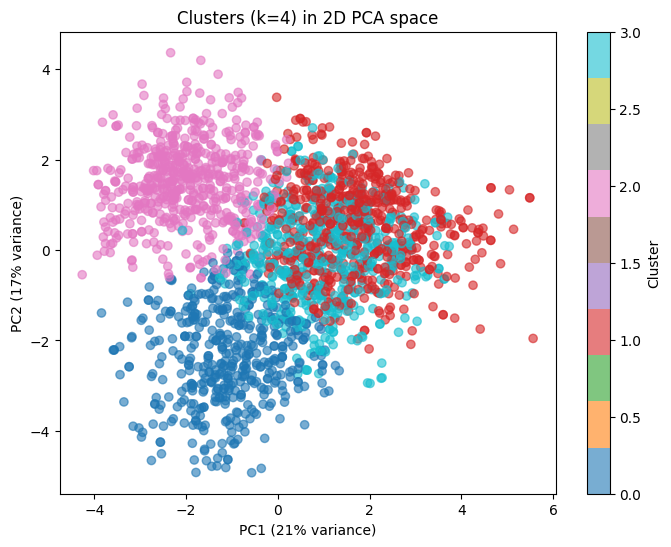

In [193]:
from sklearn.decomposition import PCA

# Reduce to 2D for plotting (run this after you've chosen k and fit the final model)
k_chosen = 4  # use whatever k you picked
kmeans = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
df_encoded['Cluster'] = labels

pca = PCA(n_components=2, random_state=42)
X_2d = np.asarray(pca.fit_transform(X))

# Scatter plot colored by cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
plt.title(f'Clusters (k={k_chosen}) in 2D PCA space')
plt.show()

## 6. Cluster profiling

Mean values of all features by cluster for persona interpretation.

In [194]:
profile = df_encoded.groupby('Cluster').mean(numeric_only=True).round(2)
profile.insert(0, 'Count', df_encoded.groupby('Cluster').size())
profile.T

Cluster,0,1,2,3
Count,470.00,618.00,566.00,571.00
ID,5395.39,5526.29,5694.01,5696.66
Income,31975.87,52512.46,73708.30,45263.58
Recency,47.61,48.68,50.67,49.29
MntWines,42.42,421.45,562.13,142.30
MntFruits,20.10,16.27,61.01,8.22
MntMeatProducts,40.63,115.89,439.86,50.33
MntFishProducts,26.64,23.09,89.22,11.58
MntSweetProducts,18.79,17.44,62.74,9.50
MntGoldProds,31.09,52.56,70.55,19.79


In [195]:
# Readable cluster persona summary
# Merge cluster labels back to original df for clean stats
df_prof = df.loc[df_david.index].copy()
df_prof['Cluster'] = labels

for c in sorted(df_prof['Cluster'].unique()):
    grp = df_prof[df_prof['Cluster'] == c]
    n = len(grp)
    
    # Education distribution
    edu_pcts = (grp['Education'].value_counts(normalize=True) * 100).round(1)
    edu_str = ', '.join([f"{k}: {v}%" for k, v in edu_pcts.items()])
    
    # Channel mix (% of total purchases)
    total_purch = grp['Total_Purchases'].sum()
    pct_web = (grp['NumWebPurchases'].sum() / total_purch * 100) if total_purch > 0 else 0
    pct_cat = (grp['NumCatalogPurchases'].sum() / total_purch * 100) if total_purch > 0 else 0
    pct_store = (grp['NumStorePurchases'].sum() / total_purch * 100) if total_purch > 0 else 0
    
    # Spending mix (% of total spend)
    total_spend = grp['Total_Spending'].sum()
    spend_cols = {'Wine': 'MntWines', 'Meat': 'MntMeatProducts', 'Fish': 'MntFishProducts',
                  'Fruit': 'MntFruits', 'Sweets': 'MntSweetProducts', 'Gold': 'MntGoldProds'}
    spend_pcts = {k: (grp[v].sum() / total_spend * 100) for k, v in spend_cols.items()} if total_spend > 0 else {}
    spend_str = ', '.join([f"{k}: {v:.1f}%" for k, v in spend_pcts.items()])
    
    print(f"{'='*60}")
    print(f"CLUSTER {c}  (n={n}, {n/len(df_prof)*100:.1f}% of customers)")
    print(f"{'='*60}")
    print(f"  Avg Age:           {grp['Age'].mean():.0f} years")
    print(f"  Avg Income:        ${grp['Income'].mean():,.0f}")
    print(f"  Avg Spending:      ${grp['Total_Spending'].mean():,.0f}")
    print(f"  Avg Family Size:   {grp['Family_Size'].mean():.1f}")
    print(f"  Avg Kids at Home:  {grp['Children_at_home'].mean():.1f}")
    print(f"  Education:         {edu_str}")
    print(f"  Shopping Channel:  Web: {pct_web:.0f}%, Catalog: {pct_cat:.0f}%, Store: {pct_store:.0f}%")
    print(f"  Spending Mix:      {spend_str}")
    print(f"  Response Rate:     {grp['Response'].mean()*100:.1f}%")
    print()

CLUSTER 0  (n=470, 21.1% of customers)
  Avg Age:           38 years
  Avg Income:        $31,976
  Avg Spending:      $180
  Avg Family Size:   2.5
  Avg Kids at Home:  0.8
  Education:         Graduate: 56.6%, Undergraduate: 31.3%, Postgraduate: 7.7%, PhD: 4.5%
  Shopping Channel:  Web: 37%, Catalog: 11%, Store: 52%
  Spending Mix:      Wine: 23.6%, Meat: 22.6%, Fish: 14.8%, Fruit: 11.2%, Sweets: 10.5%, Gold: 17.3%
  Response Rate:     10.6%

CLUSTER 1  (n=618, 27.8% of customers)
  Avg Age:           48 years
  Avg Income:        $52,512
  Avg Spending:      $647
  Avg Family Size:   2.9
  Avg Kids at Home:  1.3
  Education:         Graduate: 46.9%, PhD: 28.6%, Postgraduate: 19.1%, Undergraduate: 5.3%
  Shopping Channel:  Web: 41%, Catalog: 18%, Store: 41%
  Spending Mix:      Wine: 65.2%, Meat: 17.9%, Fish: 3.6%, Fruit: 2.5%, Sweets: 2.7%, Gold: 8.1%
  Response Rate:     18.1%

CLUSTER 2  (n=566, 25.4% of customers)
  Avg Age:           46 years
  Avg Income:        $73,708
  Avg S

# Cluster 0
Young Budget Shoppers - Lowest income ($32k), Very low spending ($180), Small families, Mixed spending across categories

Behavior - Heavy store shoppers (52%) - Very low campaign response (10%)

# Cluster 1
Dual Income No kids 
High Spenders, No Discount-needed

# Cluster 2
Bottom Earners, Younger, Online / budget Shoppers

# Cluster 3
Blue collar workers

## 7. Statistical significance

Kruskal-Wallis test: which features differ significantly across clusters?

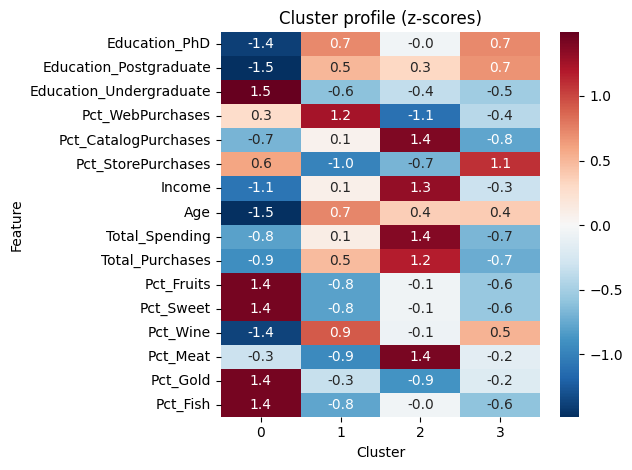

In [196]:
# Heatmap: clusters vs key features (z-score for comparability)
key_cols = ['Education_PhD', 'Education_Postgraduate', 'Education_Undergraduate', 'Pct_WebPurchases', 'Pct_CatalogPurchases', 'Pct_StorePurchases', 'Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Pct_Fruits', 'Pct_Sweet', 'Pct_Wine', 'Pct_Meat', 'Pct_Gold', 'Pct_Fish']
profile_norm = (profile[key_cols] - profile[key_cols].mean()) / profile[key_cols].std()
sns.heatmap(profile_norm.T, cmap='RdBu_r', center=0, annot=True, fmt='.1f')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.title('Cluster profile (z-scores)')
plt.tight_layout()
plt.show()

In [197]:
from scipy import stats

# For each numeric feature, run one-way ANOVA: do cluster means differ?
results = []
for col in profile.columns:
    if col == 'Count':
        continue
    groups = [df_encoded.loc[df_encoded['Cluster'] == k, col].values for k in df_encoded['Cluster'].unique()]
    # ANOVA assumes normality; use Kruskal-Wallis if data is skewed
    stat, p = stats.f_oneway(*groups)
    results.append({'feature': col, 'F_stat': stat, 'p_value': p})

sig_df = pd.DataFrame(results)
sig_df['significant'] = sig_df['p_value'] < 0.05
sig_df = sig_df.sort_values('p_value')
sig_df

,feature,F_stat,p_value,significant
1,Income,782.311000,0.000000e+00,True
29,Pct_Wine,843.937374,0.000000e+00,True
25,Total_Spending,825.598398,0.000000e+00,True
5,MntMeatProducts,909.496547,0.000000e+00,True
13,NumWebVisitsMonth,722.770178,0.000000e+00,True
11,NumCatalogPurchases,773.257851,0.000000e+00,True
23,Children_at_home,698.165520,1.144651e-319,True
34,Pct_CatalogPurchases,564.213619,1.494916e-272,True
26,Total_Purchases,517.602871,5.139682e-255,True
24,Family_Size,476.598870,4.817360e-239,True


In [198]:
results = []
for col in profile.columns:
    if col == 'Count':
        continue
    groups = [df_encoded.loc[df_encoded['Cluster'] == k, col].values for k in df_encoded['Cluster'].unique()]
    stat, p = stats.kruskal(*groups)  # Kruskal-Wallis
    results.append({'feature': col, 'H_stat': stat, 'p_value': p})

sig_df = pd.DataFrame(results)
sig_df['significant'] = sig_df['p_value'] < 0.05
sig_df.sort_values('p_value')

,feature,H_stat,p_value,significant
5,MntMeatProducts,1238.442952,3.343939e-268,True
25,Total_Spending,1215.652172,2.945686e-263,True
11,NumCatalogPurchases,1203.862928,1.064328e-260,True
3,MntWines,1195.335349,7.538325e-259,True
23,Children_at_home,1169.039045,3.824921e-253,True
29,Pct_Wine,1163.438793,6.275678e-252,True
1,Income,1152.327129,1.616023e-249,True
13,NumWebVisitsMonth,1050.501215,1.993474e-227,True
34,Pct_CatalogPurchases,974.704902,5.525116e-211,True
26,Total_Purchases,945.572314,1.152993e-204,True


In [200]:
# Export with ID and cluster assignments
pct_cols = [
    'Pct_Fruits','Pct_Sweet','Pct_Wine','Pct_Meat','Pct_Gold','Pct_Fish',
    'Pct_WebPurchases','Pct_CatalogPurchases','Pct_StorePurchases'
]

df_labels_and_pcts = df_david[['ID'] + pct_cols].copy()
df_labels_and_pcts['Cluster'] = labels

df_out = df.merge(
    df_labels_and_pcts,
    on='ID',
    how='inner',
    validate='one_to_one'
)

df_out.to_csv('../data/preprocessed/david_clustered.csv', index=False)

print(f"Saved {len(df_david)} rows to ../data/preprocessed/david_clustered.csv")
print(f"\nCluster distribution:\n{df_david['Cluster'].value_counts().sort_index()}")

Saved 2225 rows to ../data/preprocessed/david_clustered.csv

Cluster distribution:
Cluster
0    470
1    618
2    566
3    571
Name: count, dtype: int64
